# XGBoost-malli 1

XGBoost-mall on gradient boosting -pohjainen puumalli. XGBoost 
soveltuu hyvin epätasapainoisen dataan käsittelyyn ja se pystyy 
mallintamaan myös epälineaarisia yhteyksiä.

Sama aineisto kuin logistisessa regressiossa:
- Malli 1: pitkäaikaissokeri mukana
- Malli 2: ilman pitkäaikaissokeria

In [140]:
#!pip install scikit-learn
#!pip install statsmodels
#!pip install shap
#!pip install graphviz


## 1. Kirjastot ja data

In [141]:
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from xgboost import plot_importance
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import log_loss
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import statsmodels.api as sm
from xgboost import plot_tree
from matplotlib import rcParams


In [142]:
df=pd.read_csv("database_original.csv")

In [ ]:
df.drop(columns=['HDL', 'Insuliini', 'Kokonaiskolesteroli','BMI', 'Vyotaronymparys','Reipas_liikunta(pv/vk)', 'Kavely(pv/vk)'], inplace=True) 
## poistetaan muuttujat, jotka aiheuttavat multikollineaarisuutta ja iten poistettiin logisten resgression ominaisuuden huomioon ottaen, pois lukien pitkäaikaissokeri

## 2. Datan esikäsittely

Korrelaatiomatriisi ja VIF-analyysi — sama valinta kuin logistisessa regressiossa. XGBoost ei ole herkkä muuttujien skaalalle, joten RobustScaler jätetään pois mallinnuksesta.


In [144]:
corr_matrix =df.corr()

<Axes: >

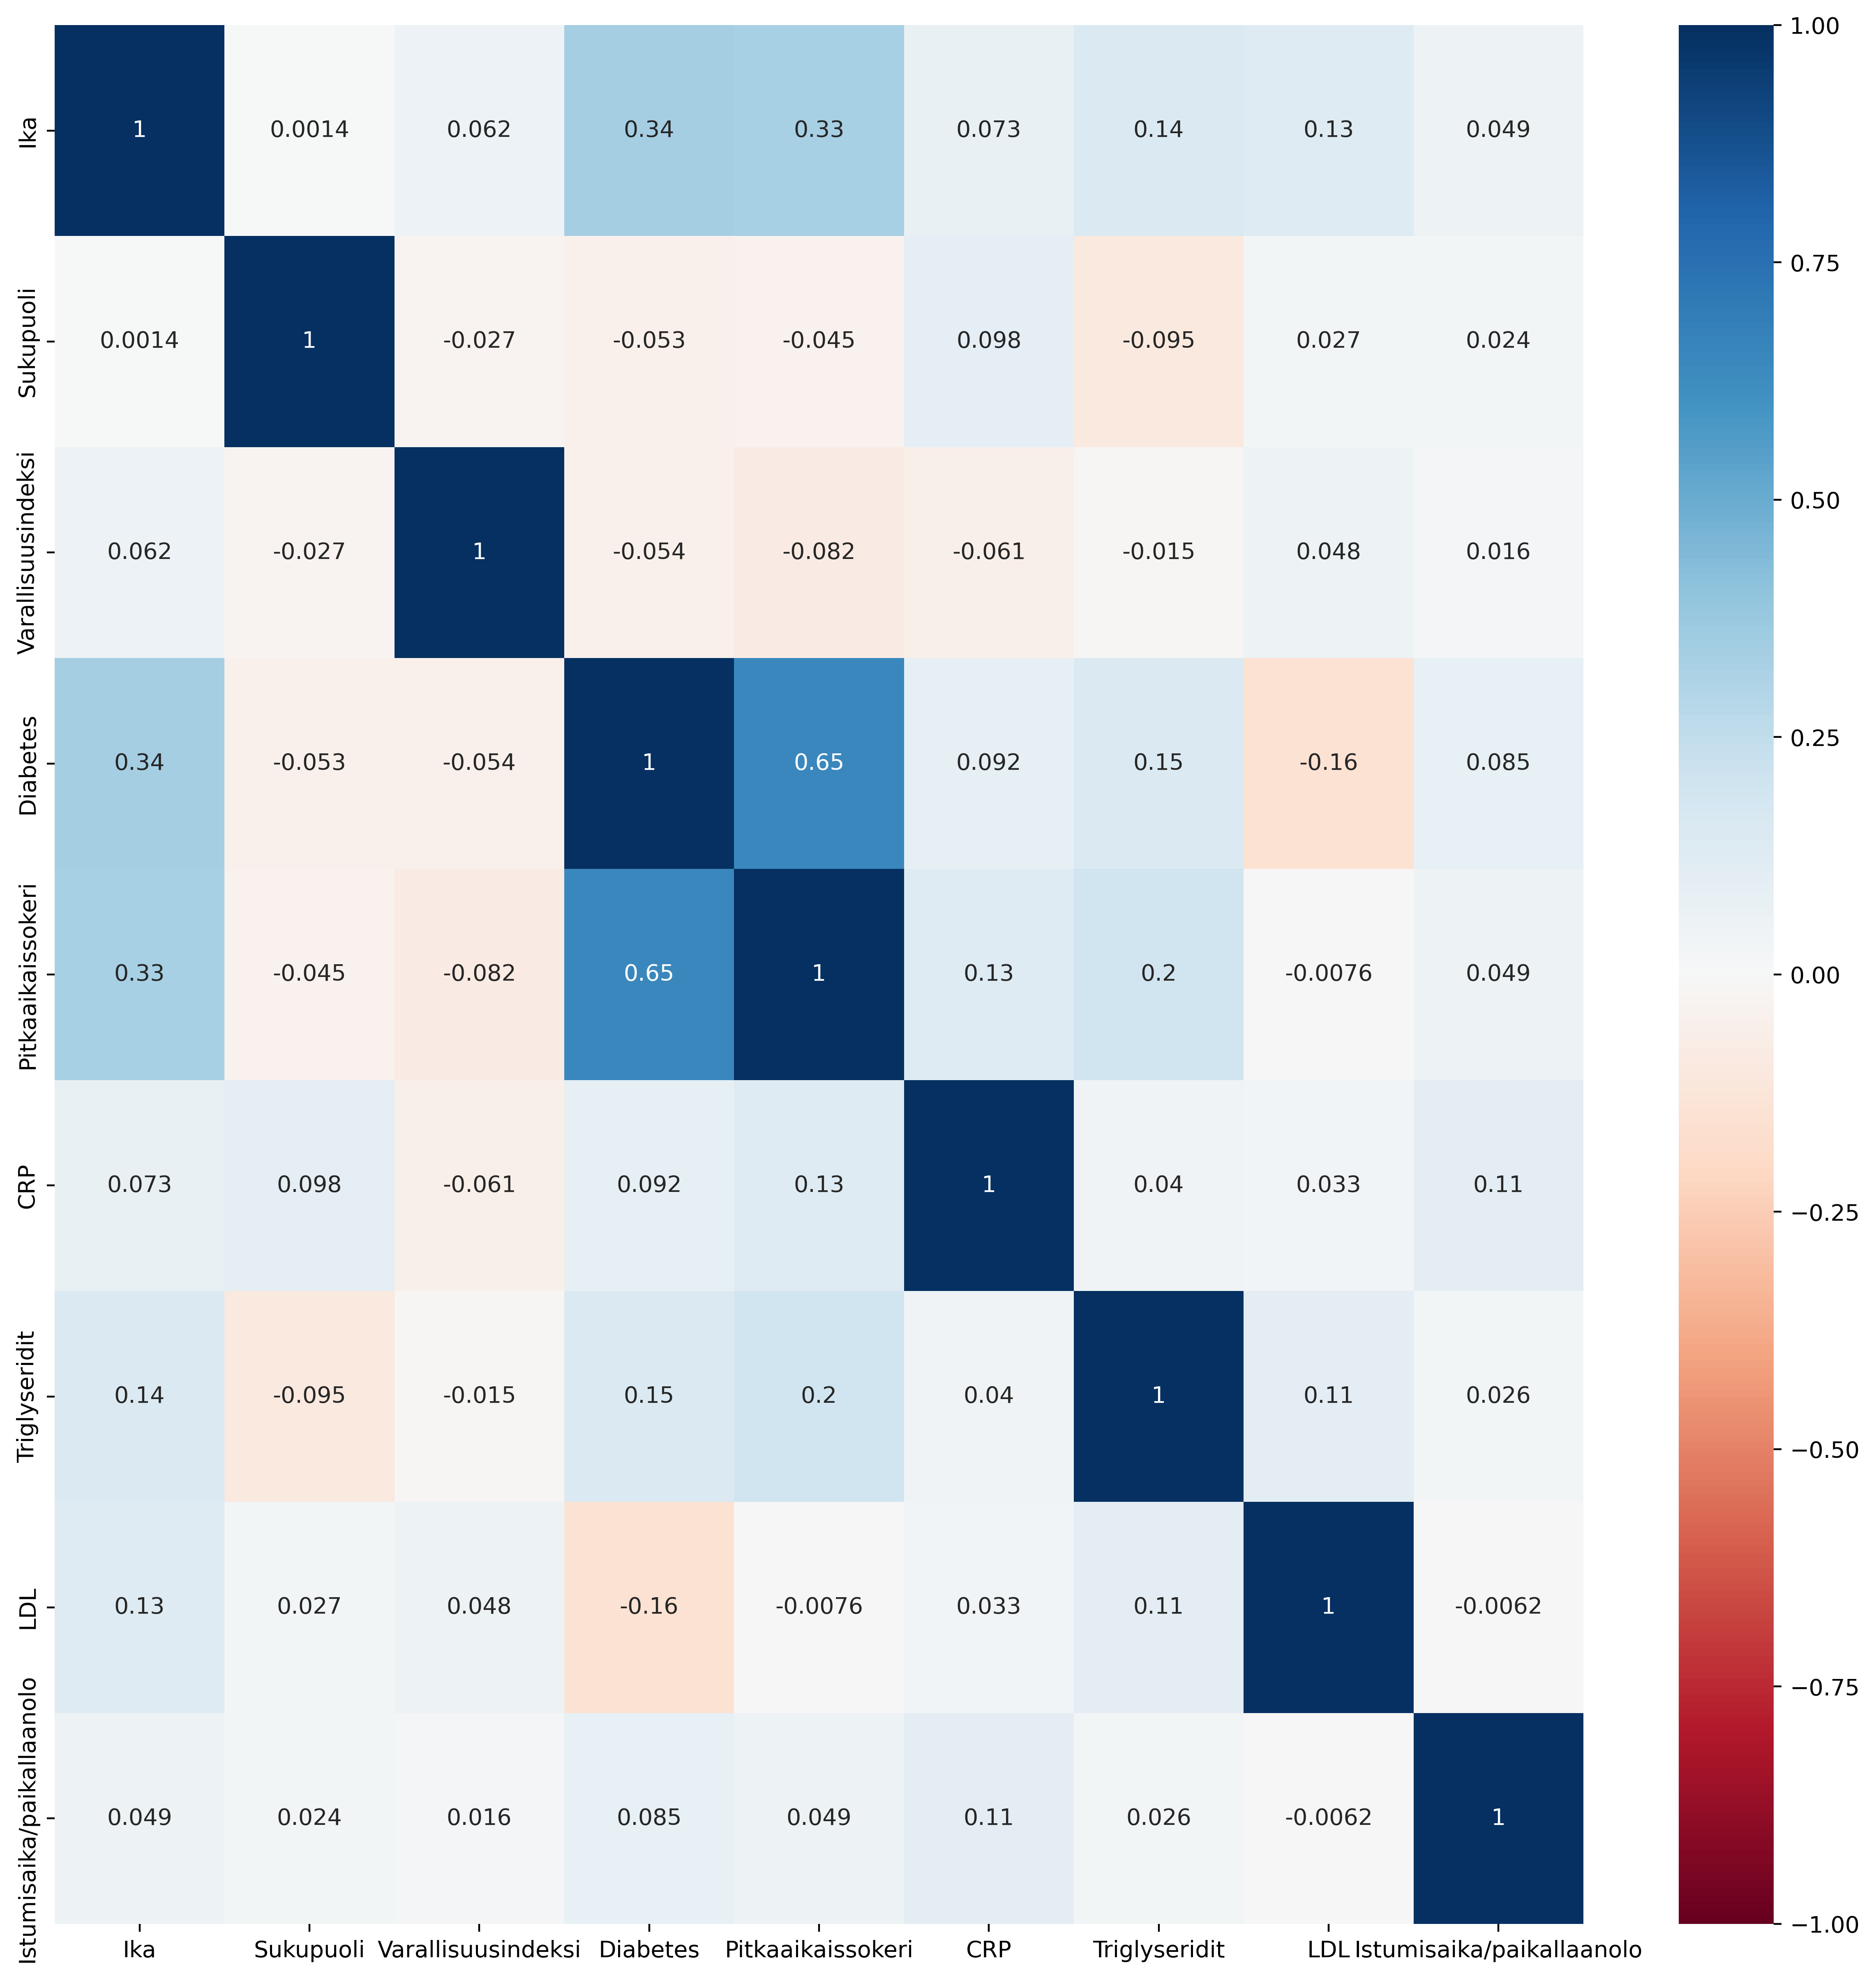

In [145]:
plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix, vmin = -1.0, vmax = 1.0, cmap ='RdBu', annot = True)

In [146]:
y = df["Diabetes"] #selitettävä muuttuja
X = df.drop("Diabetes", axis=1) #selitettävät muuttujat

vif_df = pd.DataFrame()
vif_df ["Variables"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df

,Variables,VIF
0,Ika,7.021190
1,Sukupuoli,8.370342
2,Varallisuusindeksi,4.988504
3,Pitkaaikaissokeri,17.452024
4,CRP,1.361096
5,Triglyseridit,2.305389
6,LDL,8.765188
7,Istumisaika/paikallaanolo,1.431831


In [147]:
X_train, X_test, y_train, y_test =train_test_split( X, y, test_size=0.2, random_state = 42)

In [148]:
y_train.value_counts().round(2)

Diabetes
0    2115
1     357
Name: count, dtype: int64

In [149]:
y_test.value_counts().round(2)

Diabetes
0    538
1     80
Name: count, dtype: int64



Aineistossa on luokkaimbalanssi: 86% ei-diabeetikkoja ja 14% 
diabeetikkoja. Tämä on huomioitu scale_pos_weight-parametrilla.

## 3. Mallin rakentaminen 

Mallia ei tarvitse skaalata niin kuin logistessa regresiossa, koska puupohjaiset menelmät eivät ole herkkiä muutujien mittakaavalle.


Luokkaimbalanssi (86%/14%) korjataan scale_pos_weight-parametrilla, 
joka on XGBoostin vastaava mekanismi logistisen regression 
class_weight='balanced':lle.

scale_pos_weight = enemmistöluokan määrä / vähemmistöluokan määrä
= 2115 / 357 ≈ 5.9



In [150]:
scale = 2115 / 357
xgb = XGBClassifier(scale_pos_weight=scale,n_estimators=300, max_depth=4,learning_rate = 0.05,subsample=0.8, colsample_bytree=0.8, eval_metric= "logloss") #mallin luominen
xgb.fit(X_train, y_train) # mallin kouluttaminen

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

XGBoost-malli koulutettiin käyttäen scale_pos_weight‑parametria (≈ 5.9) korjaamaan luokkien epätasapaino (86 % / 14 %). Tämä vastaa logistisen regression class_weight balanced ‑asetusta ja lisää vähemmistöluokan painoa mallin oppimisessa. Malli rakennettiin 300 matalasyvyisellä puulla (max_depth=4), pienellä oppimisnopeudella (0.05) ja osittaisella näytteenotolla (subsample=0.8, colsample_bytree=0.8) ylisovituksen estämiseksi.

## 4. Mallin arviointi

### 4.1 Ennustetut todennäköisyydet ja jakauma

In [151]:
Y_pred = xgb.predict(X_test) #luokkien ennusteet eli 0= "ei diabetestä" ja 1= "diabetes" -> tarvitaan confusion matrixissa ja accuracyssa
Y_pred_probabilities = xgb.predict_proba(X_test)[:,1] #luokkien todennäköisyydet -> AUC, ROC, riskimallit
Y_pred_probabilities

array([8.23608192e-04, 7.41601408e-01, 8.24756455e-03, 2.63951838e-01,
       6.07321213e-04, 2.26051488e-04, 1.16042513e-03, 1.13514182e-03,
       6.55469159e-03, 8.58107805e-01, 2.02370132e-03, 2.18646324e-04,
       1.40027620e-03, 4.36557084e-03, 6.65432424e-04, 7.33084884e-03,
       5.51332496e-02, 6.53121352e-01, 1.90409512e-04, 1.33648753e-01,
       1.00705377e-03, 1.10924002e-02, 9.87278342e-01, 6.12213451e-04,
       1.83244143e-03, 9.22342949e-03, 1.34385272e-03, 9.96359408e-01,
       3.31867397e-01, 1.21204434e-02, 3.88070737e-04, 3.39606684e-03,
       5.26013784e-02, 6.50337839e-04, 5.47331874e-04, 5.06133540e-03,
       1.87867816e-04, 2.83811637e-03, 7.02552676e-01, 6.65442261e-04,
       2.12543854e-03, 3.09244235e-04, 1.43573005e-02, 5.77769242e-04,
       9.87279578e-04, 8.83572459e-01, 5.22112893e-03, 3.87004548e-04,
       4.19256240e-01, 3.40969395e-03, 1.35719329e-01, 3.58174182e-02,
       9.92284656e-01, 1.37904612e-02, 2.23749295e-01, 8.07684362e-01,
      

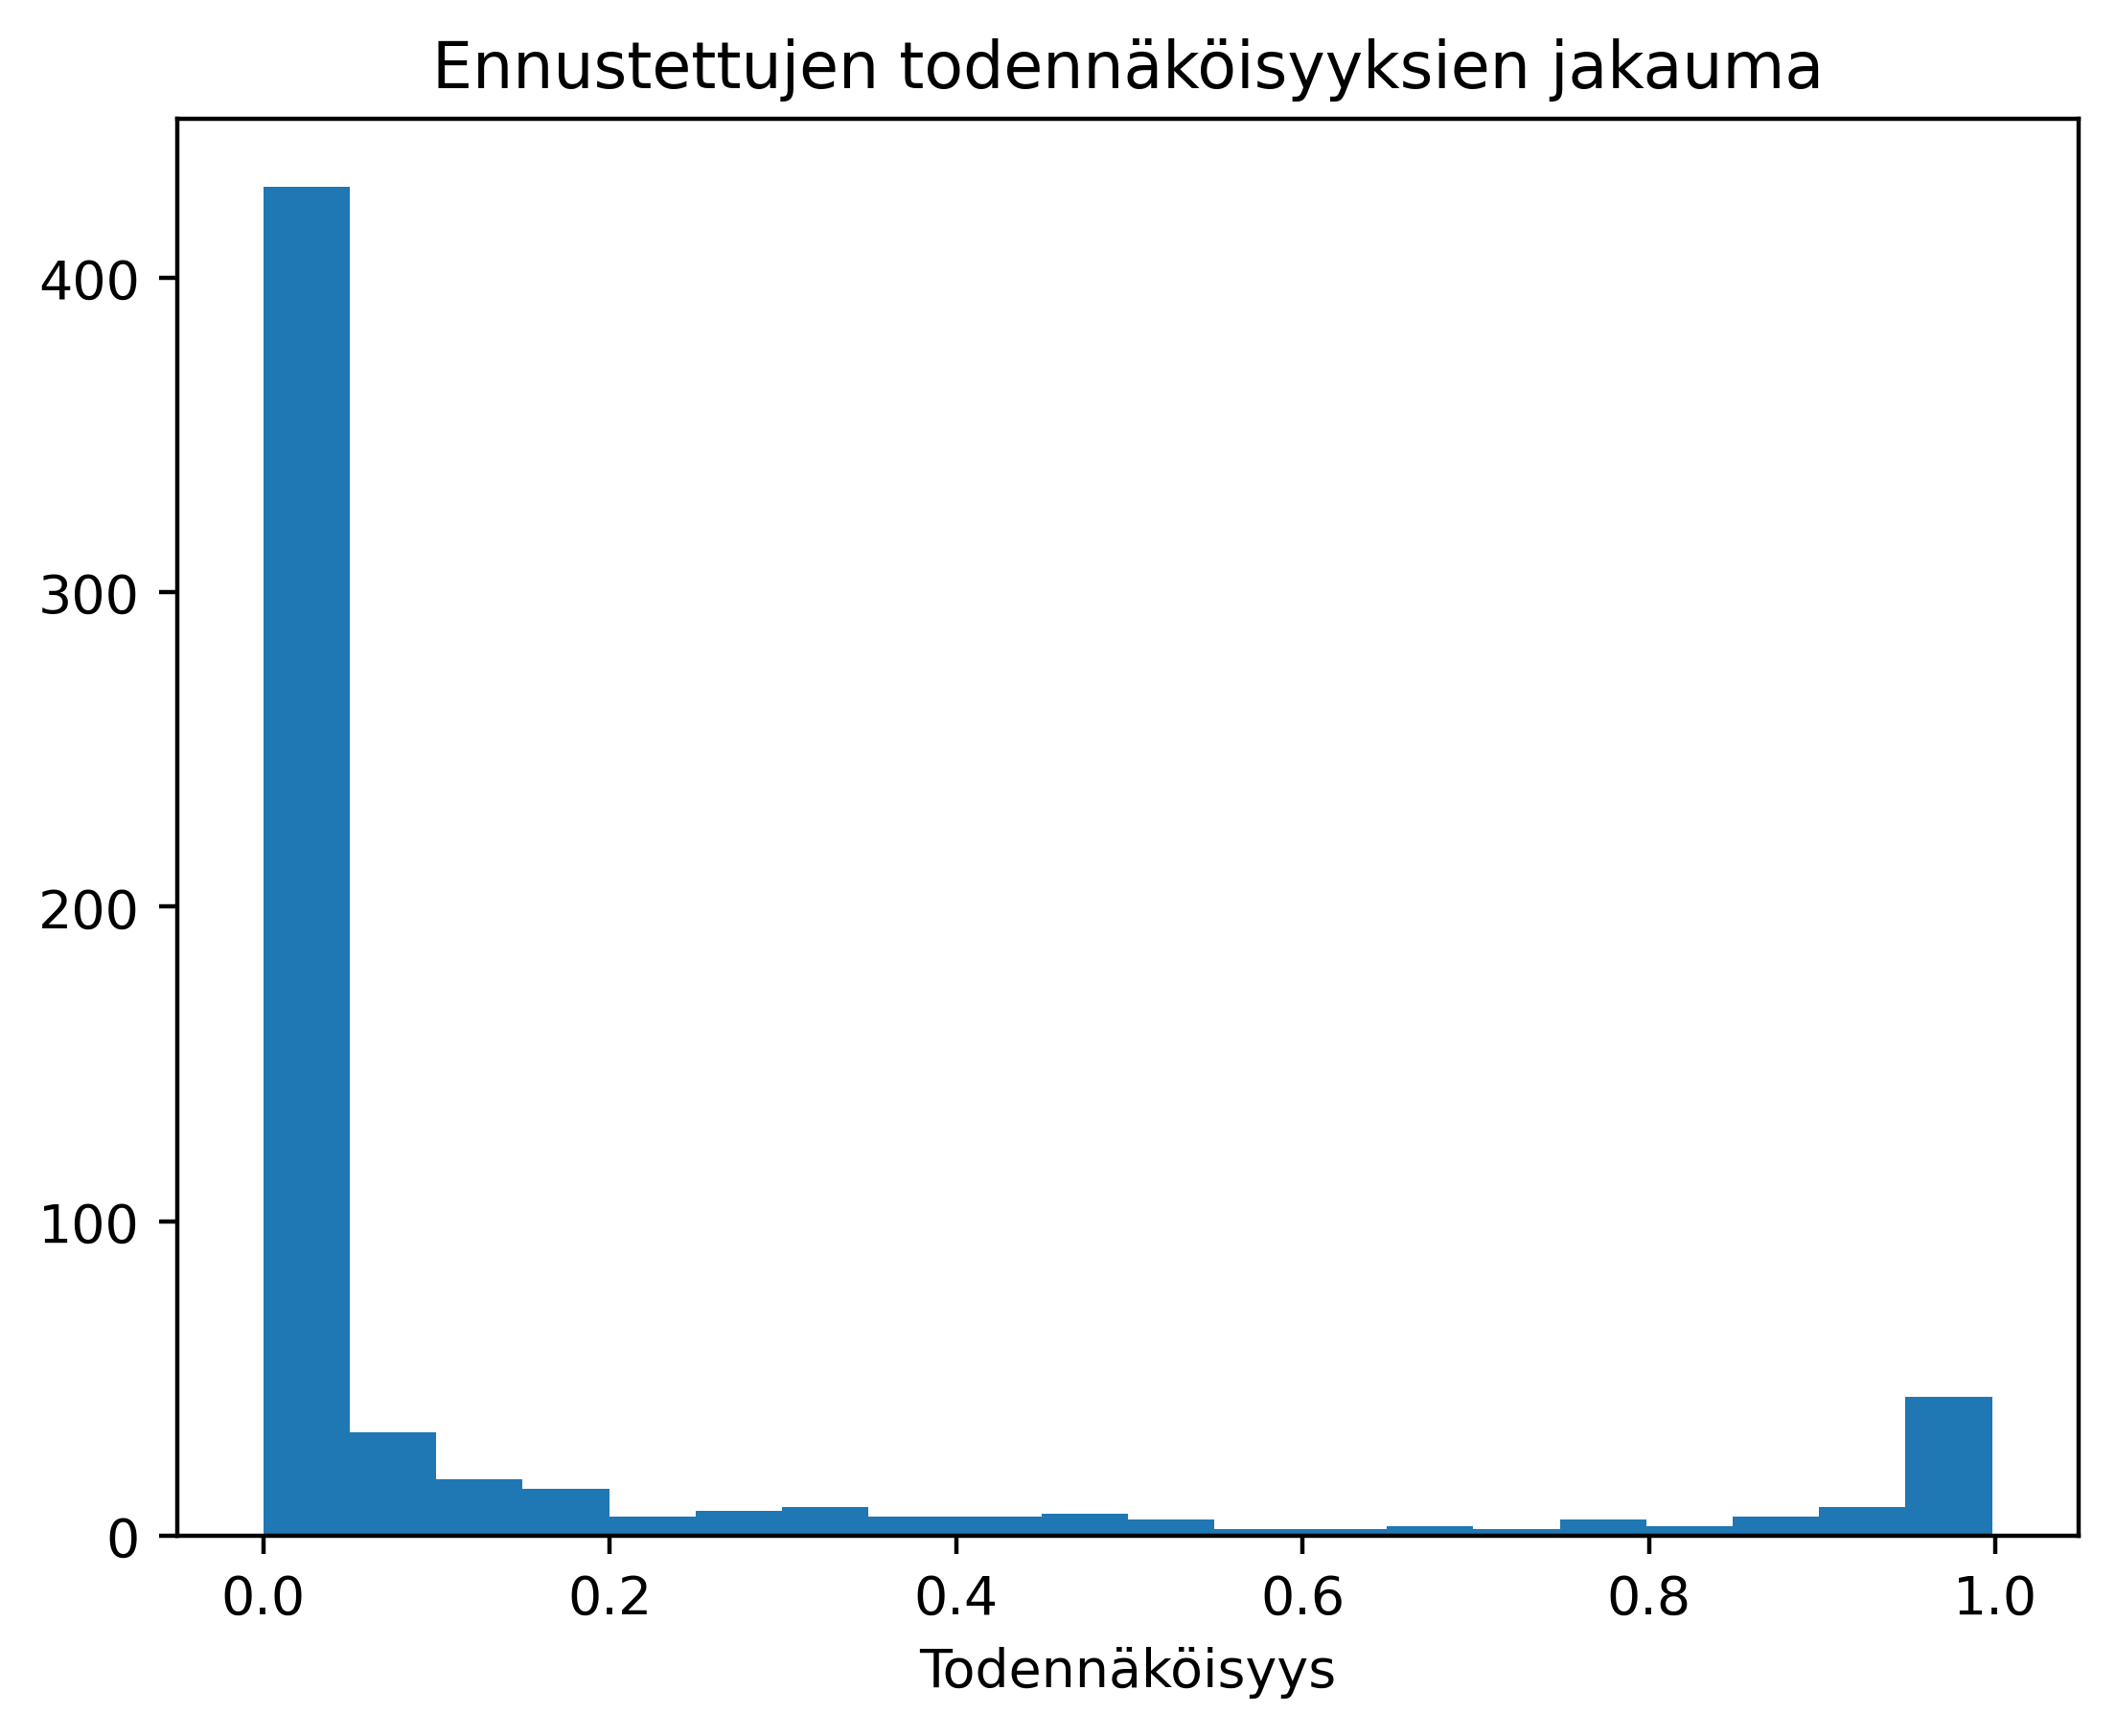

In [152]:
plt.hist(Y_pred_probabilities, bins=20)
plt.xlabel('Todennäköisyys')
plt.title('Ennustettujen todennäköisyyksien jakauma')
plt.show()



Histogrammi näyttää mallin antamien todennäköisyysennusteiden 
jakauman. Suurin piikki on lähellä nollaa — suurimmalle osalle 
testijoukon henkilöistä malli ennustaa matalaa diabetesriskiä, 
mikä vastaa aineiston luokkajakaumaa (86% ei-diabeetikkoja).

Jakauma on selvästi kaksihuippuinen — suuri piikki lähellä 
nollaa ja toinen lähellä ykköstä. Tämä kertoo että malli on 
varma ennusteissaan: se luokittelee henkilöt joko selvästi 
ei-diabeetikoiksi tai selvästi diabeetikoiksi, harvoin 
epävarmasti keskialueelle. Tämä ei kuitenkaan yksin kerro vielä mallin hyvyydestä, 
vaan jakaumaa pitää tulkita yhdessä ROC:n, recallin ja confusion matrixin kanssa.

### 4.2 Log Loss
Mittaa kuinka tarkasti ja varmasti malli antaa todennäköisyyksiä.
Mitä lähempänä 0 sitä parempi:
- alle 0.3 → erinomainen
- 0.3–0.5 → hyvä
- yli 0.7 → heikko


In [153]:
logloss = log_loss(y_test, Y_pred_probabilities)
print(logloss)

0.17595970737882202


Log Loss = 0.176 — erinomainen tulos (alle 0.3). mikä on suhteellisen matala arvo. Tämä viittaa siihen, että mallin todennäköisyysennusteet ovat melko tarkkoja ja virhe kustakin havainnosta jää keskimäärin pieneksi.

### 4.3 AUC ja ROC-käyrä
ROC-käyrä kuvaa mallin erottelukykyä eri kynnysarvoilla.
AUC mittaa mallin kykyä erotella diabeetikot ei-diabeetikoista 
eri päätöskynnysarvoilla. Arvo 1.0 on täydellinen ja 0.5 
vastaa satunnaista arvausta.

- 0.9–1.0 → erinomainen
- 0.8–0.9 → hyvä  
- 0.7–0.8 → kohtalainen

In [154]:
auc = roc_auc_score(y_test, Y_pred_probabilities)
print("AUC", auc)

AUC 0.9573187732342008


AUC = 0.957 — erinomainen. Malli erottelee diabeeteksen
ei-diabeteksestä erittäin hyvin. 



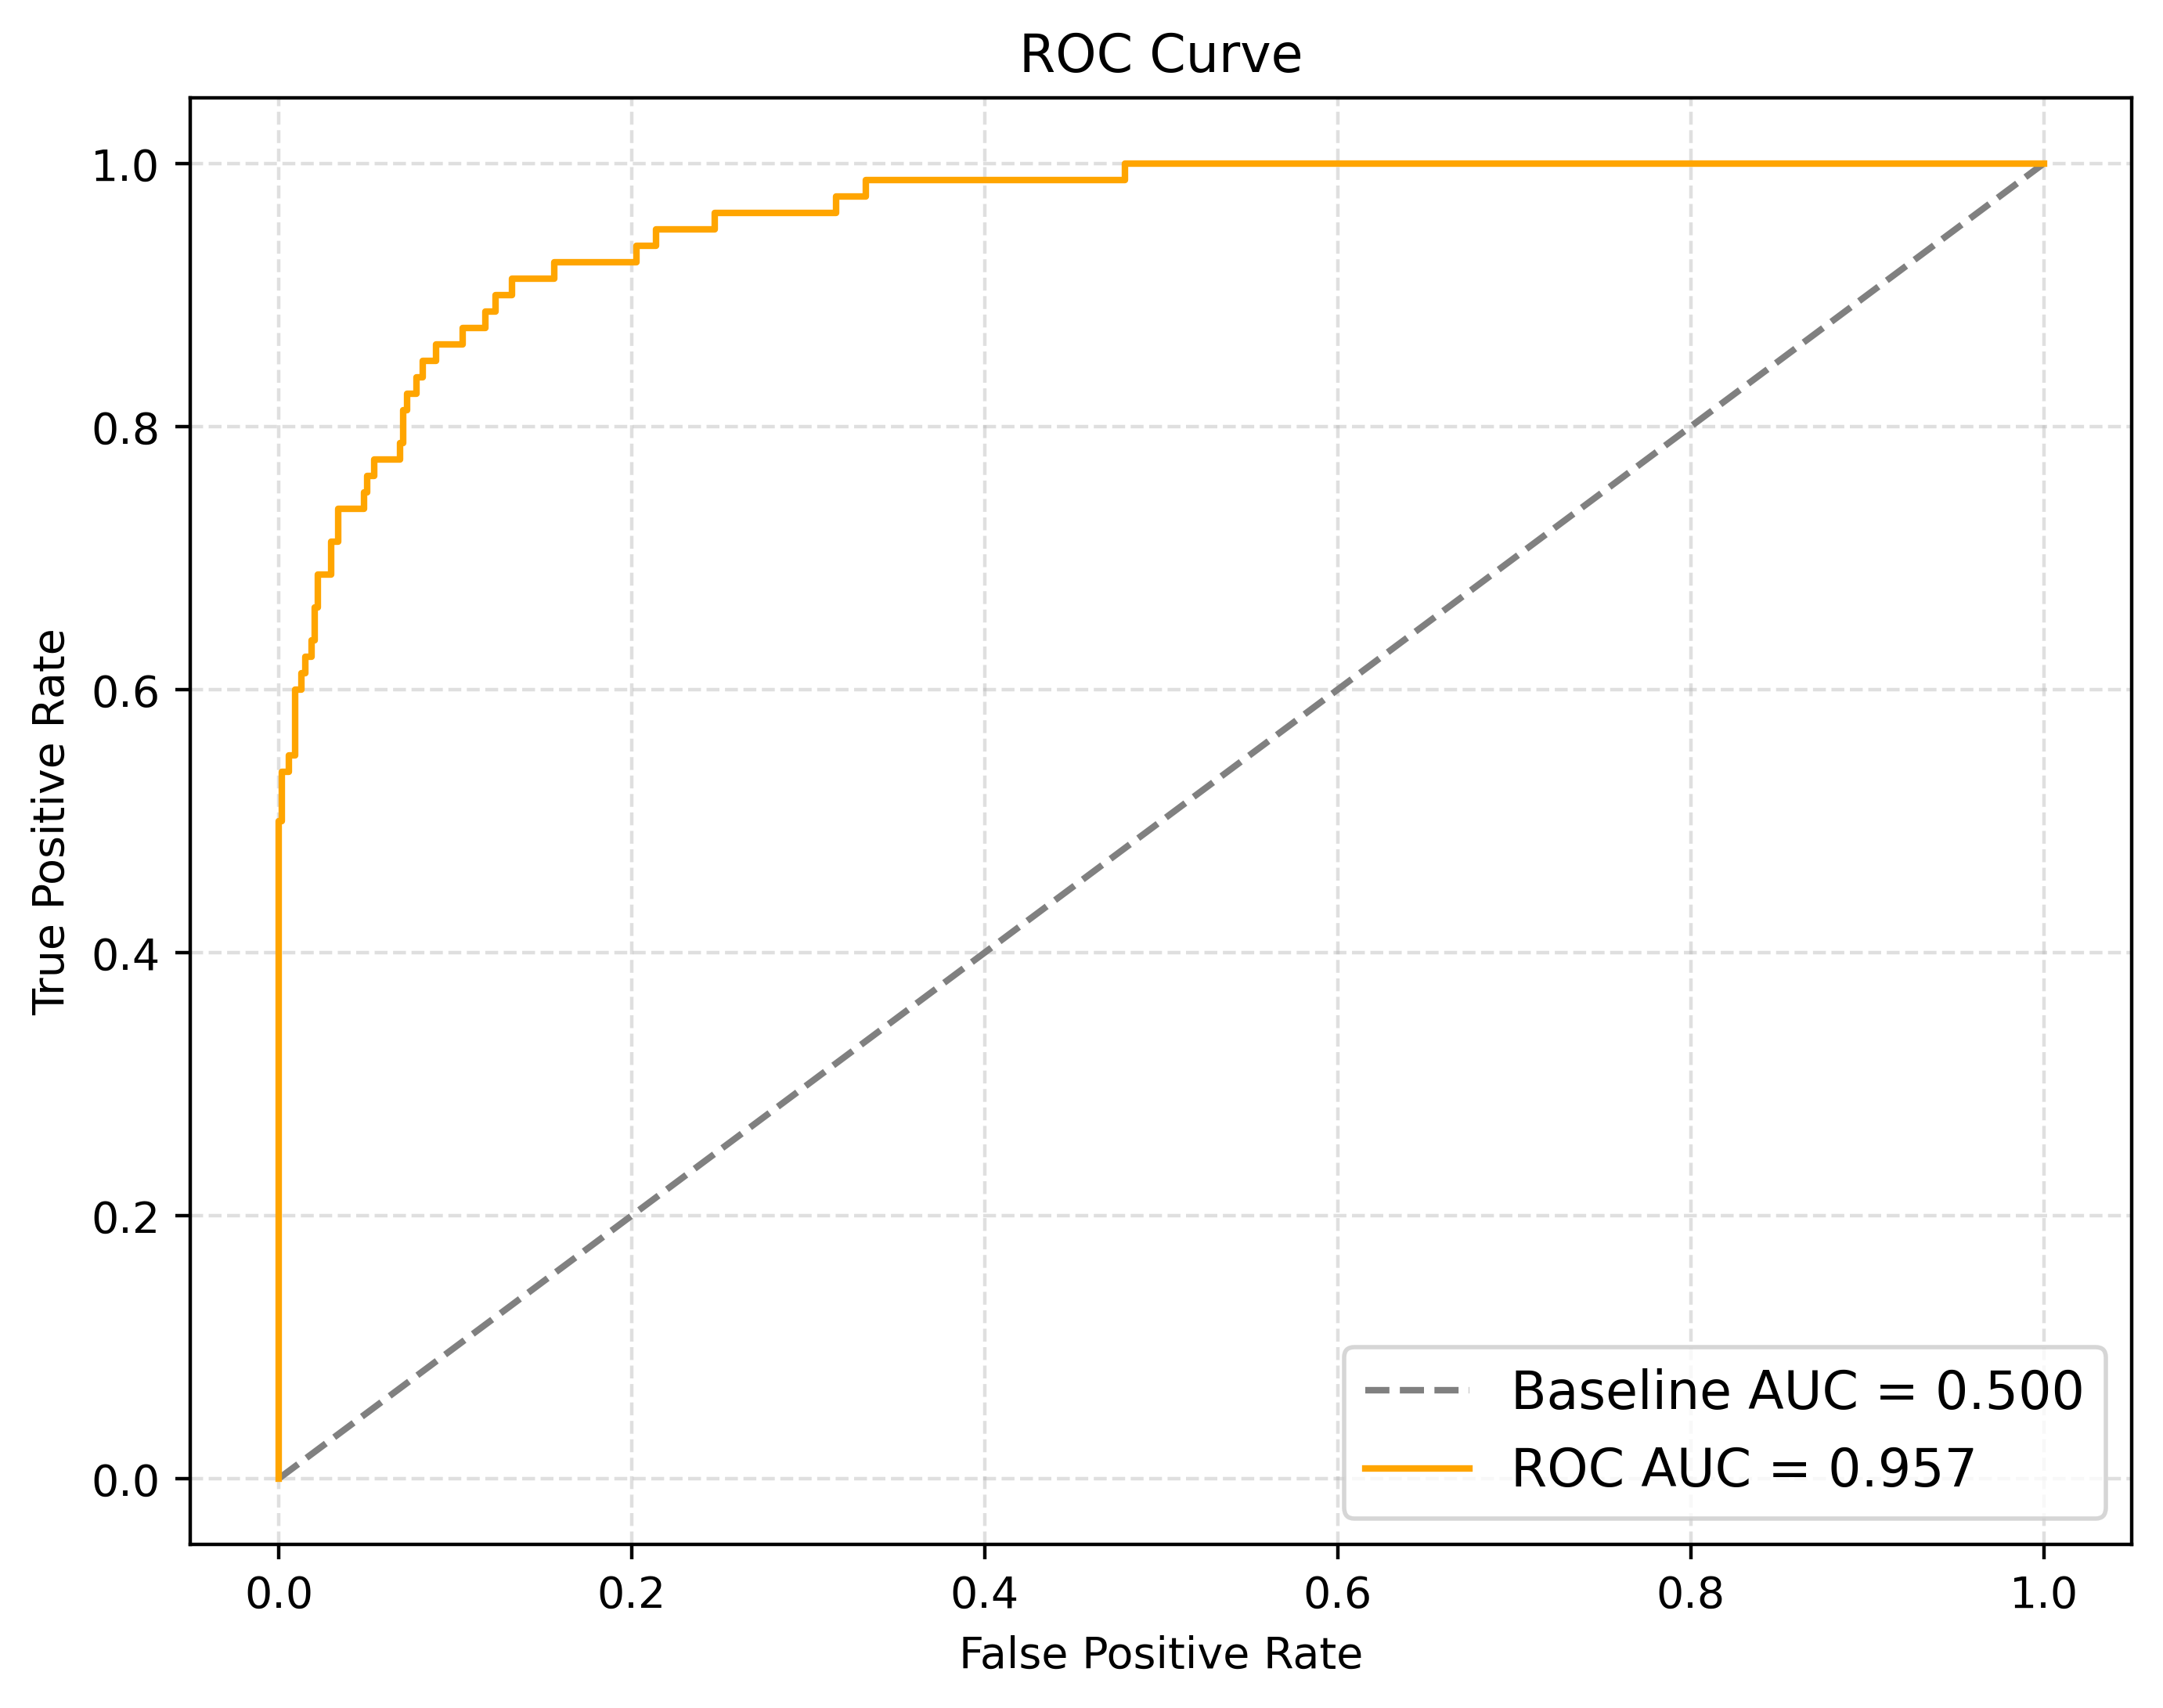

In [155]:
baseline_probs = [0 for _ in range(len(y_test))] # baseline-malli

Y_pred_probabilities = xgb.predict_proba(X_test)[:, 1] # mallin todennäköisyydet luokalle 1


baseline_auc = roc_auc_score(y_test, baseline_probs) # baseline AUC
pc_auc = roc_auc_score(y_test, Y_pred_probabilities) #predict_probalities AUC

# ROC-käyrän pisteet
baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_probs)
fpr, tpr, thresholds = roc_curve(y_test, Y_pred_probabilities, drop_intermediate=False)

# ROC-käyrä
plt.figure(figsize=(8,6))

plt.plot(
    baseline_fpr, baseline_tpr,
    linestyle='--', color='gray',
    label=f'Baseline AUC = {baseline_auc:.3f}'
)

plt.plot(
    fpr, tpr,
    color='orange',
    label=f'ROC AUC = {pc_auc:.3f}'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

ROC-käyrä nousee jyrkästi vasempaan yläkulmaan, mikä kertoo hyvästä 
herkkyydestä pienellä väärän positiivisen määrällä.

### 4.4 Confusion Matrix ja Classification Report

Binääriset ennusteet arvioidaan confusion matrixin avulla.
Kliinisessä kontekstissa recall on tärkein mittari — 
väärä negatiivinen (diabeetikko jää tunnistamatta) on 
haitallisempi kuin väärä positiivinen.

In [156]:
cm = confusion_matrix(y_test, Y_pred)
print("Confusion matrix:\n",cm)
accuracy = accuracy_score(y_test, Y_pred)
print("\nAccuracy = %.3f" % (accuracy)) 
print("\nClassification report\n")
print(classification_report(y_test, Y_pred))

Confusion matrix:
 [[516  22]
 [ 21  59]]

Accuracy = 0.930

Classification report

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       538
           1       0.73      0.74      0.73        80

    accuracy                           0.93       618
   macro avg       0.84      0.85      0.85       618
weighted avg       0.93      0.93      0.93       618



Malli tunnistaa 74% diabeetikoista oikein (recall=0.74) ja 
96% ei-diabeetikoista oikein. Vääriä negatiivisia on 21 — 
eli 21 diabeetikkoa jäi tunnistamatta. Vääriä positiivisia 
on 22 — eli 22 tervettä luokiteltiin virheellisesti 
diabeetikoiksi. Kokonaistarkkuus 0.930 on korkea.
Vaikka kokonaisaccuracy on korkea (0.93), niin tunnistamatta jäänyt diabetestapaukset n.26% voi
daan olettaa olevan vakavampi virhe kuin virheellinen positiivinen hälytys. Toisaalta precision (0.73) kertoo, että suurin osa mallin ennustamista diabetestapauksista on oikeita.

### 4.5 Feature Importance

Gain-tyyppinen tärkeys kertoo kuinka paljon kukin muuttuja 
parantaa mallin ennustekykyä päätöspuun haarautumiskohdissa 
keskimäärin. Mitä suurempi gain, sitä tärkeämpi muuttuja 
on mallille.

In [157]:

importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False))



Pitkaaikaissokeri            0.508741
Ika                          0.120846
LDL                          0.093290
Triglyseridit                0.060743
CRP                          0.058472
Sukupuoli                    0.053926
Varallisuusindeksi           0.052257
Istumisaika/paikallaanolo    0.051726
dtype: float32


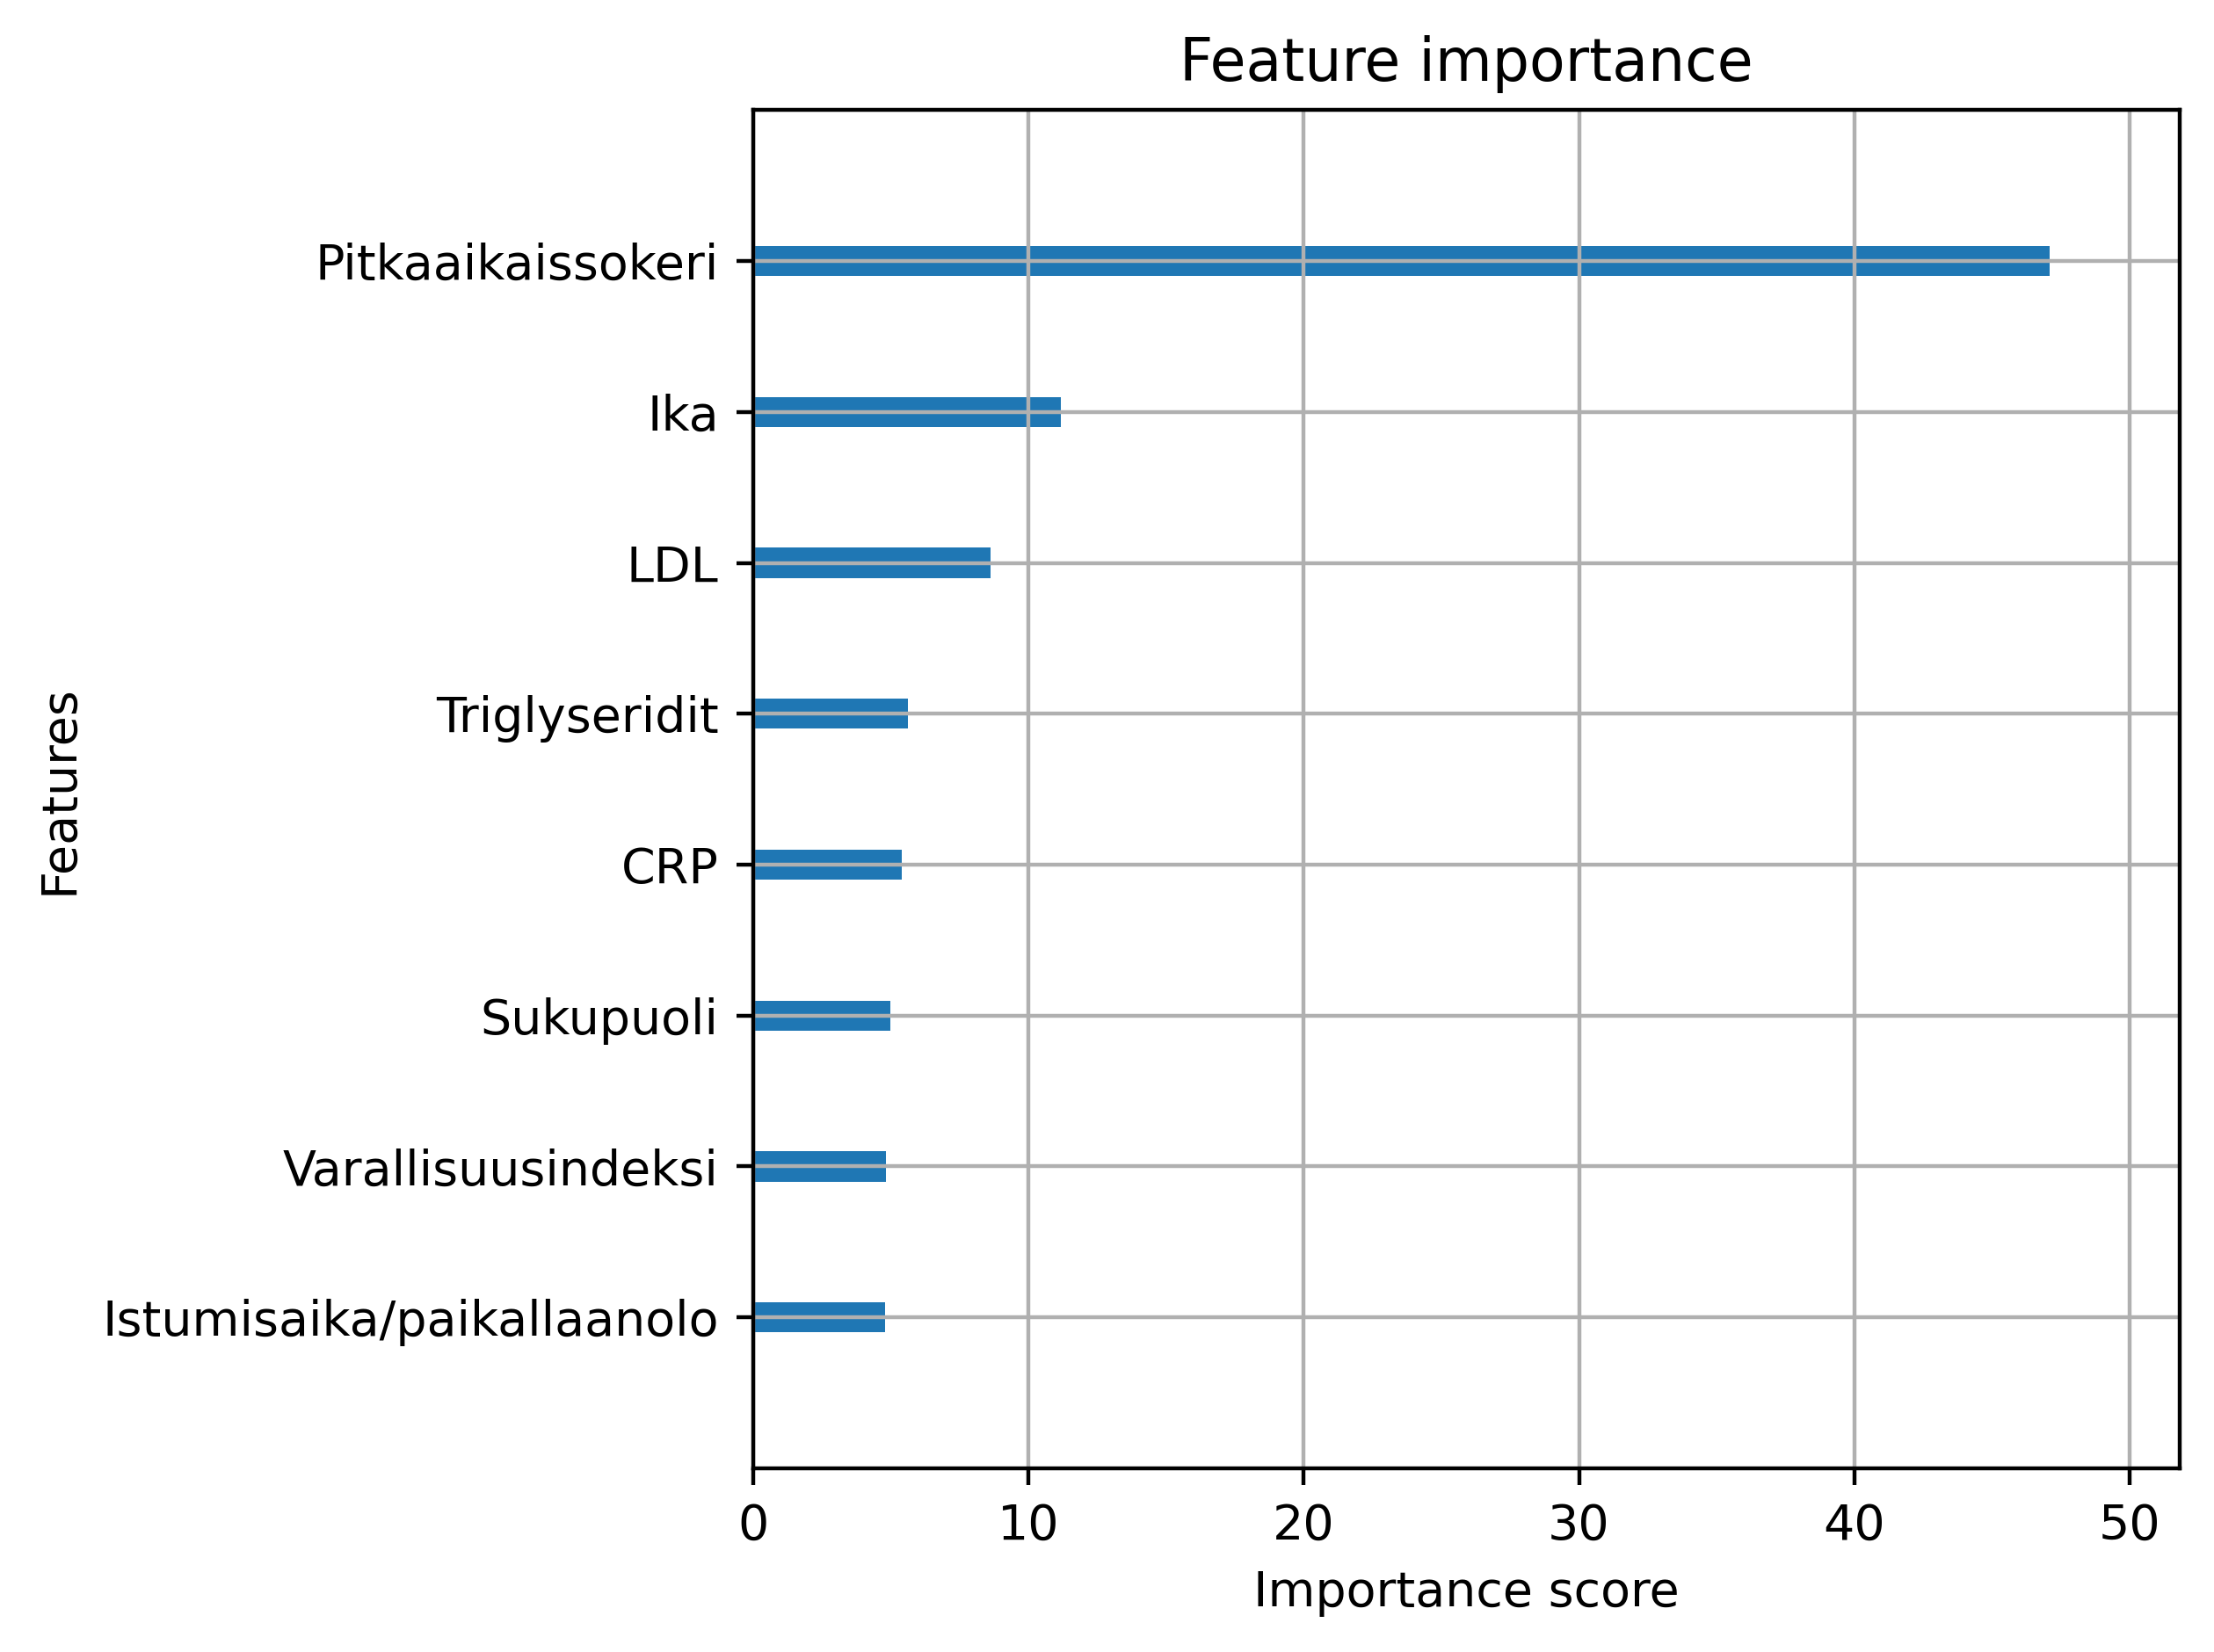

In [158]:
plot_importance(xgb, importance_type='gain',  max_num_features=8,show_values=False)
plt.tight_layout()
plt.show()

Pitkäaikaissokeri dominoi selvästi mallia — sen gain-arvo 
(0.51) on yli 4-kertainen seuraavaan muuttujaan (ikä, 0.12) 
verrattuna. Pitkäaikaissokeri on ylivoimaisesti merkitsevin 
yksittäinen diabeteksen ennustaja mallissa.

Ikä ja LDL ovat seuraavaksi tärkeimmät. Muut muuttujat 
— triglyseridit, CRP, sukupuoli, varallisuusindeksi ja 
istumisaika — jakavat lopun tärkeyden tasaisemmin 
arvojen vaihdellessa 0.05–0.06 välillä.

### 4.6 SHAP-analyysi

SHAP (SHapley Additive exPlanations) selittää yksittäisten 
muuttujien vaikutuksen mallin päätöksiin sekä suunnan että 
voimakkuuden osalta. Toisin kuin feature importance, SHAP 
kertoo myös lisääkö vai vähentääkö muuttujan arvo 
diabetesriskiä.

tulkinta:

SHAP-kuvassa punaiset pisteet kuvaavat korkeita muuttuja-arvoja ja siniset matalia. 
Oikealle siirtyvät arvot kasvattavat diabeteksen ennustettua todennäköisyyttä ja vasemmalle siirtyvät pienentävät sitä.



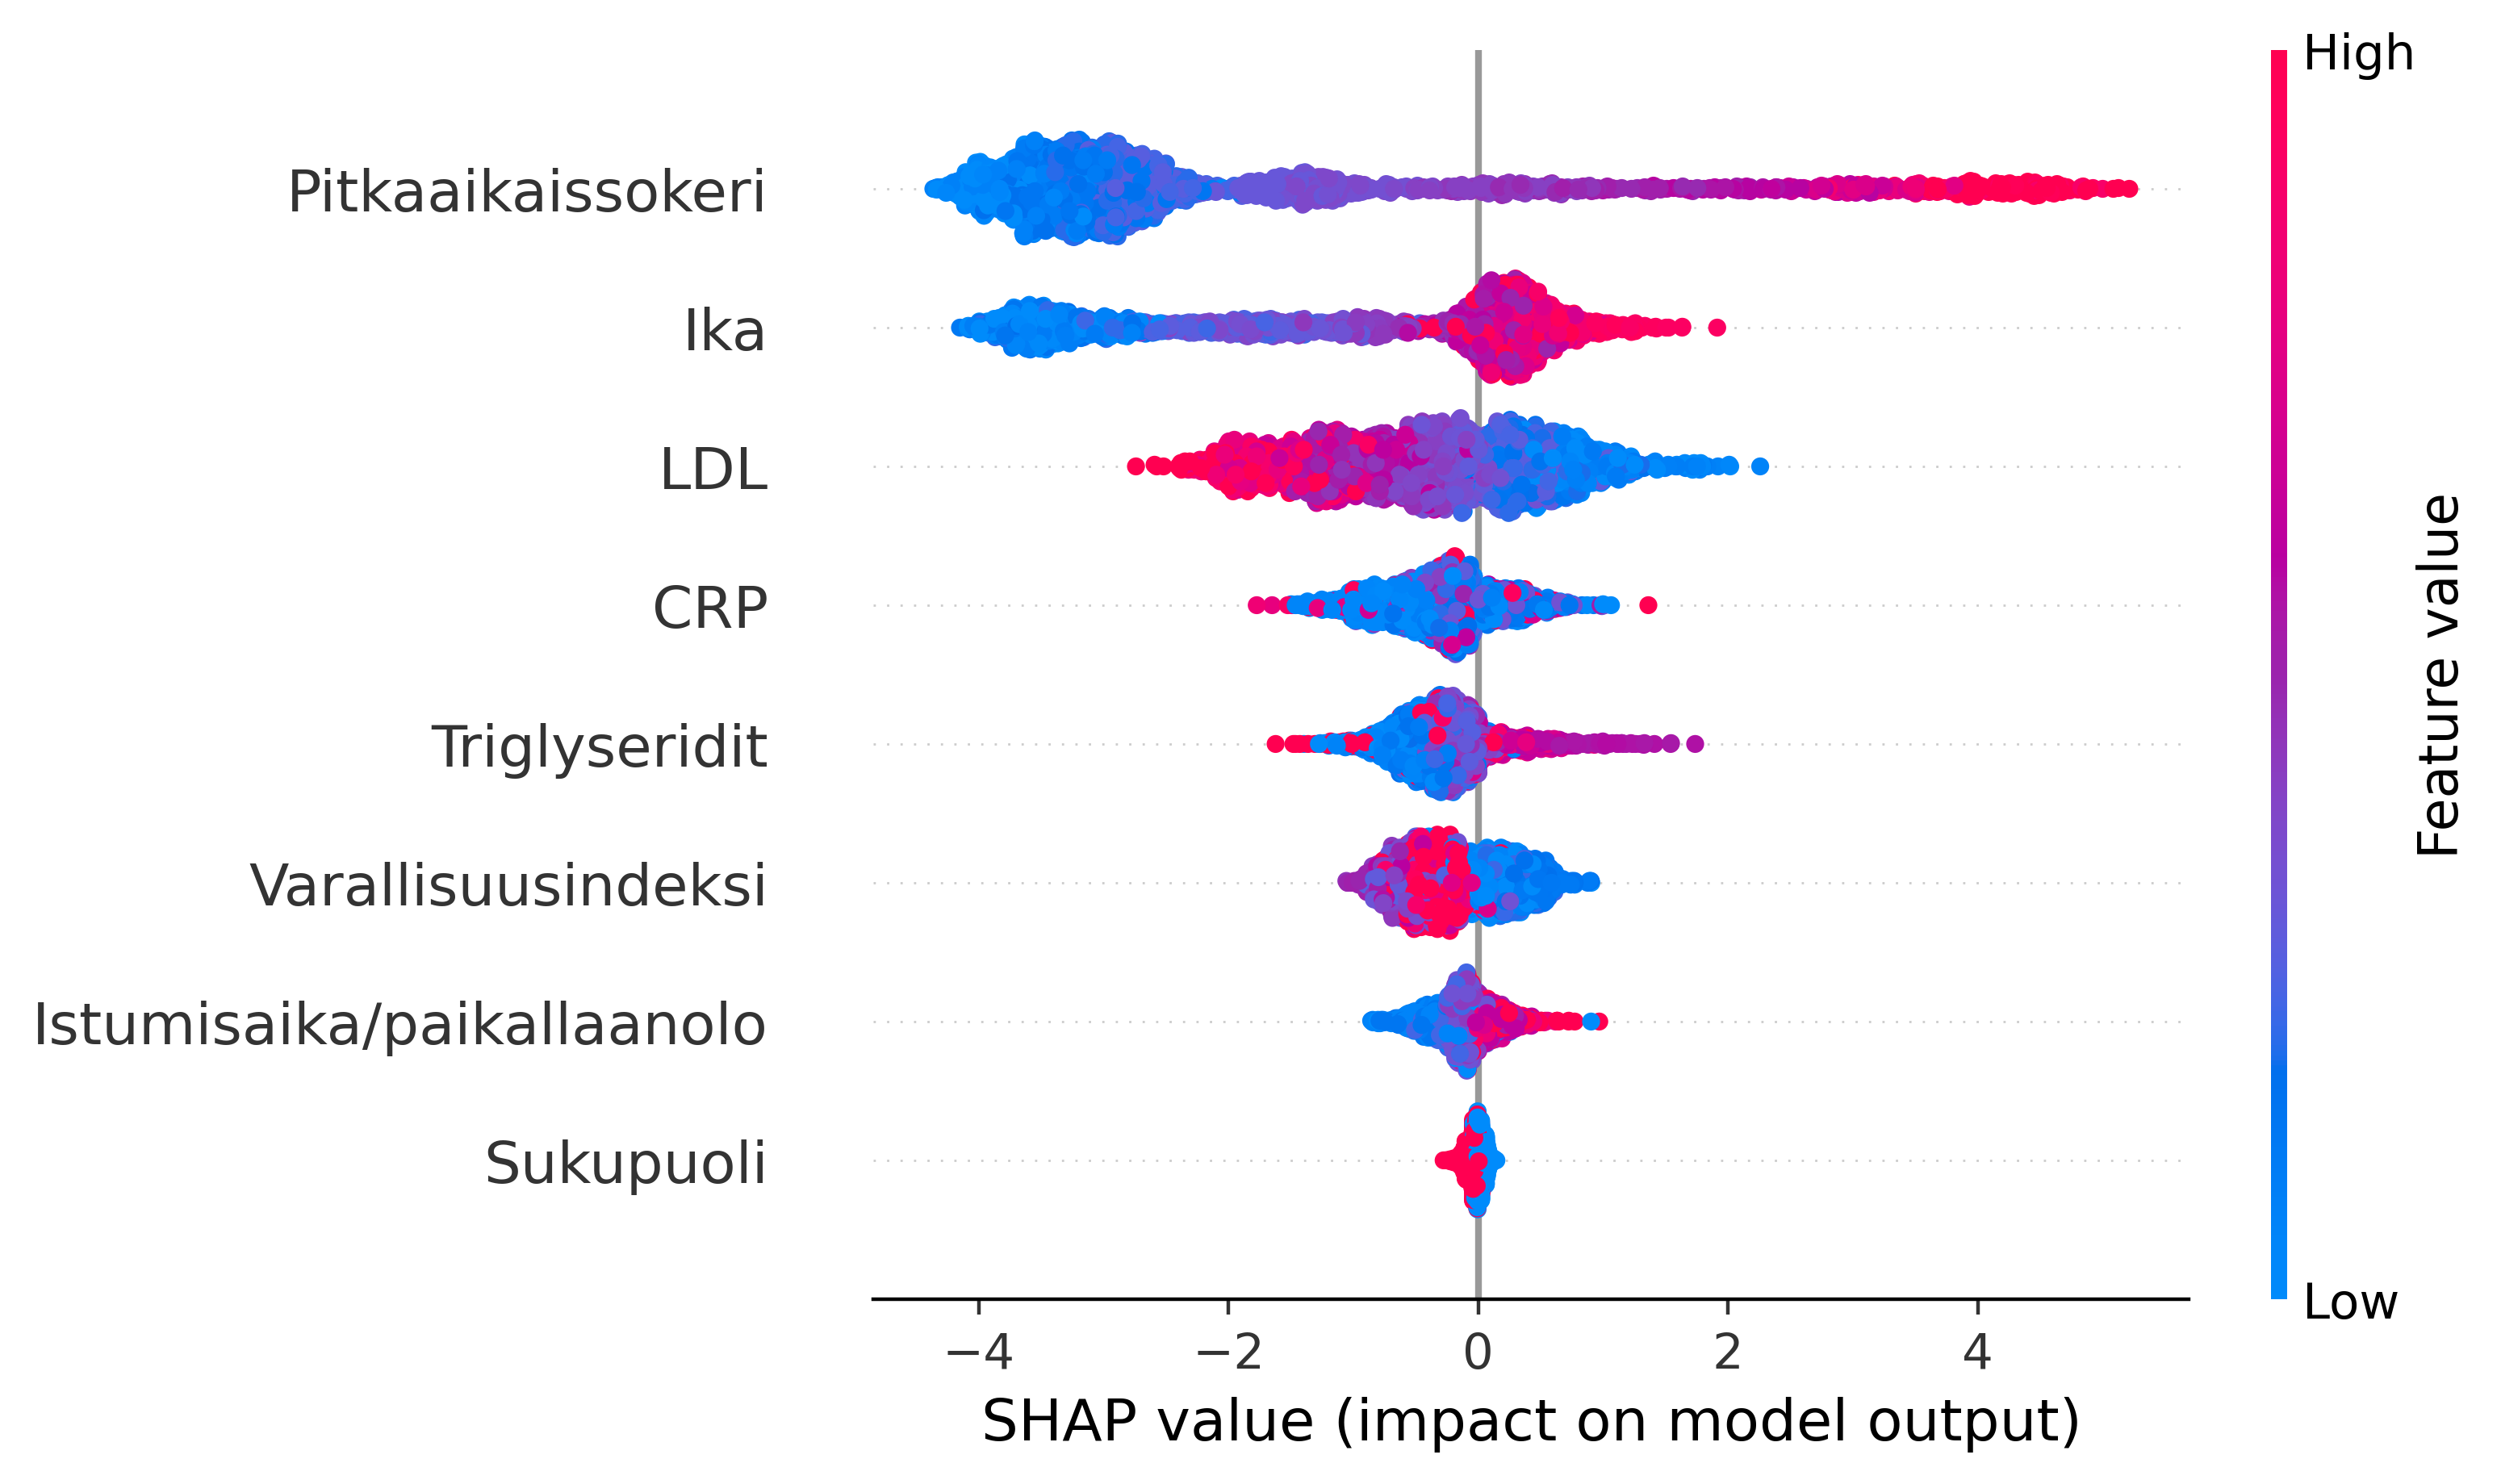

In [159]:
explainer = shap.TreeExplainer(xgb) #Mitkä muutujat vaikuttavat mallin päätöksiin ja miten.
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train)




SHAP-arvot vahvistavat feature importancen tulokset ja kertovat 
lisäksi vaikutuksen suunnan:

-Pitkäaikaissokeri: Selvästi tärkein muuttuja. Korkea arvo 
(punainen) työntää ennustetta voimakkaasti kohti diabetesta, 
matala arvo (sininen) poispäin. Hajonta on suurin kaikista 
muuttujista.

-Ikä: Korkea ikä lisää diabetesriskiä, matala ikä vähentää 
— selkeä ja looginen yhteys.

-LDL: Mielenkiintoinen käänteinen kuvio — korkea LDL 
(punainen) näyttää vähentävän riskiä ja matala LDL lisäävän. 
Tämä on biologisesti yllättävä (voi heijastaa 
kolesterolilääkityksen vaikutusta aineistossa.)

-Varallisuusindeksi: SHAP-arvot keskittyvät lähelle nollaa 
— vaikutus on pieni mutta havaittavissa.

-CRP ja triglyseridit: Kohonneet arvot lisäävät riskiä 
lievästi — linjassa tulehduksen ja metabolisen oireyhtymän 
kanssa.

Sukupuoli: SHAP-arvot keskittyvät lähes nollaan — 
vahvistaa että sukupuolella ei ole merkittävää vaikutusta 
tässä mallissa.


### 4.7 Päätöspuuvisualisointi

XGBoostin yksittäiset päätöspuut visualisoidaan havainnollistamaan 
mallin päätöksentekoprosessia. äätöspuu havainnollistaa yhden yksittäisen boosting-vaiheen rakennetta, 
mutta sitä ei tule tulkita koko mallin päätöksentekona. XGBoostin ennuste muodostuu kaikkien puiden yhteisvaikutuksesta.

In [160]:
rcParams['figure.dpi'] = 400
fig, ax = plt.subplots(figsize=(80, 50))
plot_tree(xgb, tree_idx=6, ax=ax)
plt.show()

Tässä puussa ensimmäinen jako tehdään pitkäaikaissokerin 
perusteella (< 0.99) — vahvistaa sen dominoivan roolin mallissa. 
Seuraavilla tasoilla käytetään ikää, LDL:ää ja triglyseriditä 
tarkentamaan ennustetta. 
